# Multioutput Models

This section provides examples for implementing concepts related to multioutput models. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section.





[1] [Hinton, Geoffrey E., and Ruslan R. Salakhutdinov. "Reducing the dimensionality of data with neural networks." science 313.5786 (2006): 504-507.](https://www.science.org/doi/10.1126/science.1127647)

[2] [Halder, Rakesh, Krzysztof J. Fidkowski, and Kevin J. Maki. "Non‐intrusive reduced‐order modeling using convolutional autoencoders." International Journal for Numerical Methods in Engineering 123.21 (2022): 5369-5390.](https://onlinelibrary.wiley.com/doi/full/10.1002/nme.7072)

[3] [What is an Autoencoder? IBM blog post.](https://www.ibm.com/think/topics/autoencoder)

The first block of code imports the packages required for this section of the Jupyter book.

> __*NOTE*__: You may see some warnings when running the code in this section. These can be safely ignored. 

In [ ]:
import torch
from scimlstudio.models import FeedForwardAutoencoder, POD, FeedForwardNeuralNetwork
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from pyDOE3 import lhs
from scimlstudio.utils import Standardize, Normalize
from scimlstudio.utils import evaluate_vector
from gpytorch.mlls import ExactMarginalLogLikelihood
from scimlstudio.models import SingleOutputGP

# defining the device and data types
args = {"device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'), "dtype": torch.float32}

## Environment Model Function

The non-intrusive reduced order modeling method will be demonstrated using the [Environment Model Function (EMF)](https://www.sfu.ca/~ssurjano/environ.html) that can be described as follows:

$$h(s,t|\textbf{x})= \frac{M}{\sqrt{4\pi Dt}}\text{exp}(\frac{-s^2}{4Dt}) + \frac{1_{t>\tau}M}{\sqrt{4\pi D(t-\tau)}}\text{exp}(\frac{-(s-L)^2}{4D(t-\tau)}).$$

This is the same function that was used in previous sections to demonstrate the [POD]((https://computationaldesignlab.github.io/surrogate-methods/pod.html)) and [autoencoder](https://computationaldesignlab.github.io/surrogate-methods/autoencoder.html) dimensionality reduction method. More details about the function and contour plots of the function can be found in these previous sections. The EMF is evaluated on a 32 x 32 grid for $(s,t)$ which means that there are a total of 1024 values to model for the EMF over this grid.

In the previous sections, it has been demonstrated how to reduce the dimensionality of the EMF and also reconstruct the function using POD and autoencoders. Here, in this section, it will be demonstrated how to predict the EMF for a given set of input values for $M, D, L$ and $\tau$. This represents a prediction problem where the entire field output of the EMF must be predicted given a set of inputs. The next block of code defines the EMF. 

In [31]:
# defining the grid for the function
s_grid = torch.linspace(0.0, 2.50, 32, **args)
t_grid = torch.linspace(15.0, 60.0, 32, **args)
Sgrid, Tgrid = torch.meshgrid(s_grid, t_grid, indexing='ij')

def env_model_function(x: torch.Tensor) -> torch.Tensor:
    """
        Parameters
        ----------
        x: torch.Tensor
            2D tensor array with the inputs to the function

        Returns
        -------
        y: torch.Tensor
            Values of the EMF evaluated for the given inputs

    """

    # extracting values of variables
    M = x[0]
    D = x[1]
    L = x[2]
    tau = x[3]

    first_term = (M/torch.sqrt(4 * torch.pi * D * Tgrid)) * torch.exp(-(Sgrid**2)/(4*D*Tgrid))
    second_term = (M/torch.sqrt(4 * torch.pi * D * (Tgrid - tau))) * torch.exp(-((Sgrid - L) ** 2)/(4*D*(Tgrid - tau)))
    second_term[torch.isnan(second_term)] = 0.0
    y = first_term + second_term

    return y

We will first generate training and testing data for the non-intrusive reduced order model. 1000 training samples and 50 testing samples will be generated. Latin hypercube sampling (LHS) is used to generate the training and testing data for the model. 

In [44]:
# defining the bounds
l_bounds = torch.tensor([7.0, 0.02, 0.01, 30.01], **args)
u_bounds = torch.tensor([13.0, 0.12, 3.0, 30.295], **args)

# training data generation
train_samples = torch.tensor(lhs(n=4, samples=200, criterion='cm', iterations=100), **args)
xtrain = l_bounds + (u_bounds - l_bounds) * train_samples
ytrain = torch.stack([env_model_function(x) for x in xtrain]) # this uses a 32x32 grid leading to a total of 1024 outputs
print(f"Shape of training data: {xtrain.shape}")

# testing data generation
test_samples = torch.tensor(lhs(n=4, samples=50, criterion='cm', iterations=100), **args)
xtest = l_bounds + (u_bounds - l_bounds) * test_samples
ytest = torch.stack([env_model_function(x) for x in xtest])
print(f"Shape of testing data: {xtest.shape}")

Shape of training data: torch.Size([200, 4])
Shape of testing data: torch.Size([50, 4])


## Proper Orthogonal Decomposition + Gaussian Process models

As described above, the NIROM surrogate modeling method uses a dimensionality reduction method along with a interpolation or regression model to predict high-dimensional outputs. One example of such a model can be constructed using POD as the dimensionality reduction method and GP models as the interpolation model for the low-dimensional latent space. One bottleneck that can occur with the use of GP models for the latent space is that the latent space is multi-dimensional. There are GP models that can predict multiple outputs, but these are out of the scope of this book. So, we will use a collection of independent GP models, one for each latent variable, to model the latent variables.

The next block of code performs POD to generate the latent space for the EMF training data and also generates the latent variables by projecting the high-dimensional data to the low-dimensional latent space.

In [49]:
# defining the pod model and generating the latent variables for the training data
pod = POD(s_train=ytrain.flatten(1).mT, ric=0.9999, snapshot_transform=Standardize(ytrain.flatten(1)))
pod.fit()
latent_vars_pod = pod.encoding(ytrain.flatten(1).mT)

The next code block trains a collection of GP models where each GP model is trained to predict one of the latent variables obtained from POD. The trained GP models are then stored in a list which can be used later to generate the predictions of the GP models and predict the high-dimensional field output of the EMF. The training process of the GP models follows the procedure introduced in the [GP modeling section](https://computationaldesignlab.github.io/surrogate-methods/gp_models/gp_models.html).

In [48]:
gp_models_pod = []
for i in range(latent_vars_pod.shape[-1]):
    latent_train = latent_vars_pod[:,i]
    gp = SingleOutputGP(x_train=xtrain, y_train=latent_train.reshape(-1,1), output_transform=Standardize, input_transform=Normalize)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # loss function 
    optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer
    gp.fit(training_iterations=500, mll=mll, optimizer=optimizer)
    gp_models_pod.append(gp)

/Users/gallifrey/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/Users/gallifrey/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


Now, that the complete model has been trained, the next code block demonstrates how to generate predictions for the testing data using the list of GP models. The high-dimensional field output prediction is then obtained by stacking the predictions from the GP model and using the decoding function from the POD class to generate the field output prediction. 

Since we are using GP models to predict the latent variables, we can also obtain the variance in the prediction of the latent variables. We can then use the variance in the prediction of the latent variables to obtain the variance in the prediction of the field output by using the following expression. 

In [ ]:
latent_predictions_pod = []
latent_var_pod = []
for gp in gp_models_pod:
    latent_pred, latent_std = gp.predict(xtest)
    latent_predictions_pod.append(latent_pred)
    latent_var_pod.append(latent_std**2)
latent_predictions = torch.stack(latent_predictions_pod, dim=1).squeeze(-1)
latent_variance = torch.stack(latent_var_pod, dim=1).squeeze(-1)

predictions_pod = pod.decoding(latent_predictions)
predictions_pod_reshaped = predictions_pod.reshape([xtest.shape[0],32,32])

torch.Size([50, 19])


After generating the predictions, the next block of code plots the field output predictions along with the variance in the prediction and the absolute error between the prediction and the testing data. This is similar to how the field output data contours were plotted in the previous sections. 

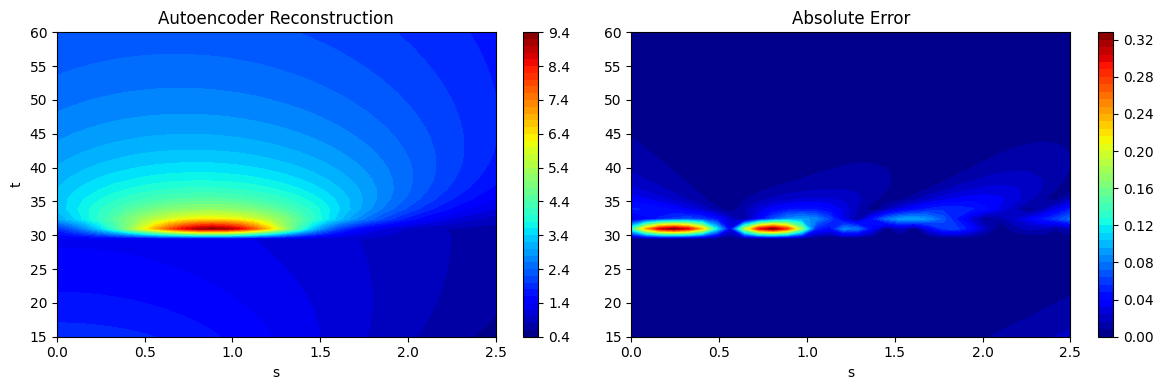

In [47]:
# plotting the reconstructions
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_pod_reshaped[15].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder Reconstruction")
fig.colorbar(contour, ax=ax[0])

contour = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(ytest[15] - predictions_pod_reshaped[15]).numpy(force=True), 
                         levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour, ax=ax[1])

plt.tight_layout()

In [5]:
# utility function from neural networks section of book for initializing the weights of the netwo
def init_weights(m):
    """
        Function for initializing the weights using glorot (or xavier) normal initialization
    """

    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_normal_(m.weight) # change this for other init methods
        m.bias.data.fill_(0.0)

# defining the encoder
encoder = torch.nn.Sequential(
    torch.nn.Linear(ytrain.flatten(1).shape[-1], 256),
    torch.nn.SiLU(),
    torch.nn.Linear(256, 64),
    torch.nn.SiLU(),
    torch.nn.Linear(64, 16)
).to(**args)

# defining the decoder
decoder = torch.nn.Sequential(
    torch.nn.Linear(16, 64),
    torch.nn.SiLU(),
    torch.nn.Linear(64, 256),
    torch.nn.SiLU(),
    torch.nn.Linear(256, ytrain.flatten(1).shape[-1]),
).to(**args)

# initializing the networks
encoder.apply(init_weights)
decoder.apply(init_weights)

# defining the autoencoder
autoencoder = FeedForwardAutoencoder(x_train=ytrain.flatten(1), encoder=encoder, decoder=decoder, data_transform=output_transform)

In [6]:
# defining the networks for the latent space model
# two different networks are defined since different networks are required for POD and autoencoders
network_pod = torch.nn.Sequential(
    torch.nn.Linear(xtrain.shape[-1], 8),
    torch.nn.SiLU(),
    torch.nn.Linear(8, 8),
    torch.nn.SiLU(),
    torch.nn.Linear(8, 16),
).to(**args)

network_ae = torch.nn.Sequential(
    torch.nn.Linear(xtrain.shape[-1], 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, 16),
).to(**args)

# initializing weights
network_ae.apply(init_weights)
network_pod.apply(init_weights)

# defining the feedforward neural networks for learning the mapping from input space to latent space
# at the start the output data is set to the high dimensional outputs and then changed within the NonIntrusiveReducedOrderModel class 
model_ae = FeedForwardNeuralNetwork(xtrain, ytrain.flatten(1), network_ae, input_transform, output_transform)
model_pod = FeedForwardNeuralNetwork(xtrain, ytrain.flatten(1), network_pod, input_transform, output_transform)

In [7]:
# creating the pod based non intrusive reduced order model
pod_rom = NonIntrusiveReducedOrderModel(x_train=xtrain, y_train=ytrain.flatten(1), dim_red_model=pod, latent_space_model=model_pod)

# creating the autoencoder based non intrusive reduced order model
ae_rom = NonIntrusiveReducedOrderModel(x_train=xtrain, y_train=ytrain.flatten(1), dim_red_model=autoencoder, latent_space_model=model_ae)

## Training the nonintrusive reduced order model

The autoencoder neural network created in the previous code block can be trained using the `fit` method from the `FeedForwardAutoencoder` class object. The `fit` method is identical to the `fit` method of the `FeedForwardNeuralNetwork` class described in the [neural network section](https://computationaldesignlab.github.io/surrogate-methods/nn_models.html) of this book. This is because autoencoders are a special neural network architecture but they are trained using the same method as all other neural networks. Refer to the [neural networks section](https://computationaldesignlab.github.io/surrogate-methods/nn_models.html) for more details of the `fit` method. 

Here, the autoencoders are trained using the ADAM optimizer with a learning rate of 1e-3 for 5000 epochs with a batch size equal to the number of samples in the training data. The following block of code trains the autoencoder neural networks on the training data generated earlier. 

In [8]:
# training the pod rom
loss_func = torch.nn.MSELoss() 
pod_ls_optimizer = torch.optim.Adam(pod_rom.latent_space_model.parameters, lr=1e-3)
pod_rom.fit(latent_space_optimizer = pod_ls_optimizer, loss_func = loss_func, batch_size = xtrain.shape[0],latent_space_epochs = 1000)

# training the autoencoder rom
autoencoder_optimizer = torch.optim.Adam(ae_rom.dim_red_model.parameters, lr=1e-3)
ae_ls_optimizer = torch.optim.Adam(ae_rom.latent_space_model.parameters, lr=1e-3)
ae_rom.fit(latent_space_optimizer = ae_ls_optimizer, loss_func = loss_func, dim_red_optimizer = autoencoder_optimizer, dim_red_epochs = 1000, batch_size = xtrain.shape[0], latent_space_epochs = 1000)

## Reconstructing the EMF using the autoencoder network

Once the autoencoder has been trained, it can be used to project the high-dimensional EMF data to a low-dimensional latent space. The low-dimensional latent space can then be used to reconstruct the original high-dimensional data. The projection to the latent space can be done using the `encoding` method of the `FeedForwardAutoencoder` class and the reconstruction from the latent space can be done using the `decoding` method of the `FeedForwardAutoencoder` class. This is demonstrated in the following code block:

In [9]:
# using the predict method to generate the predictions for the test data
predictions_pod = pod_rom.predict(xtest)
predictions_pod_reshaped = predictions_pod.reshape([xtest.shape[0],32,32])

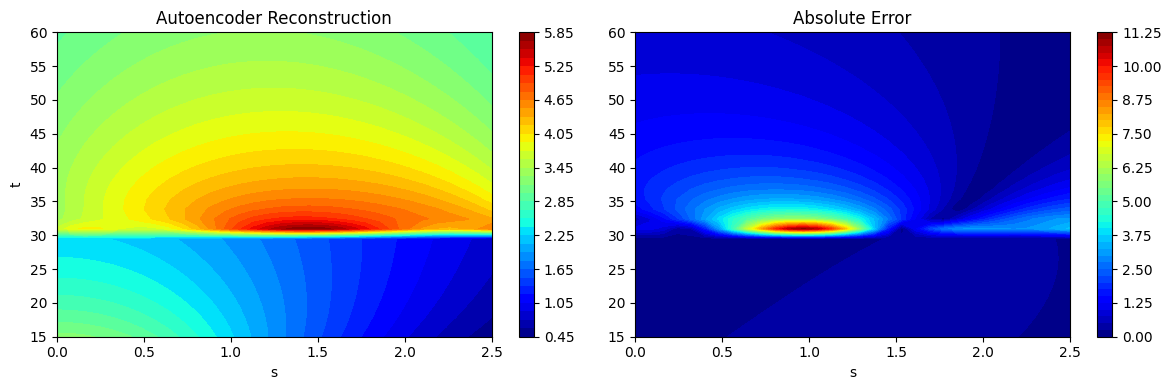

In [10]:
# plotting the reconstructions
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_pod_reshaped[15].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder Reconstruction")
fig.colorbar(contour, ax=ax[0])

contour = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(ytest[15] - predictions_pod_reshaped[15]).numpy(force=True), 
                         levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour, ax=ax[1])

plt.tight_layout()

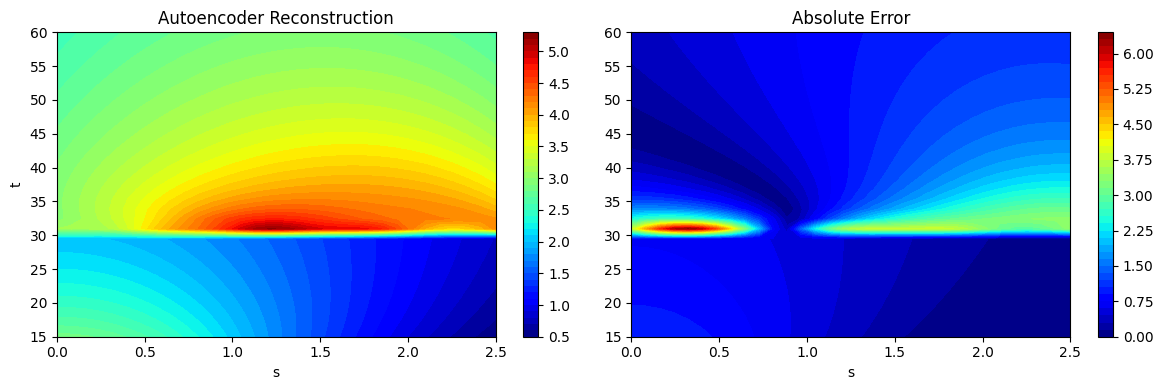

In [11]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_pod_reshaped[20].numpy(force=True), levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder Reconstruction")
fig.colorbar(contour, ax=ax[0])

contour = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(ytest[20] - predictions_pod_reshaped[20]).numpy(force=True), levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour, ax=ax[1])

plt.tight_layout()

## NRMSE Calculation and Comparison with POD

We calculate the NRMSE for each grid point as an error metric to evaluate the overall accuracy of the autoencoder model. We plot the countours of the NRMSE to illustrate how the error is distributed over the 2D grid of the EMF. We also create a POD model for the EMF in an identical manner to [POD section](https://computationaldesignlab.github.io/surrogate-methods/pod.html) of the book to compare the POD method with the autoencoder method. 

The next block of code defines the POD model for the EMF function using the same procedure as outline in the [POD section](https://computationaldesignlab.github.io/surrogate-methods/pod.html) of the book.

In [24]:
# defining the POD model and fitting it to the training data
transform = Standardize(xtrain.flatten(1))
pod = POD(s_train=xtrain.flatten(1).mT, ric=0.9999, snapshot_transform=transform)
pod.fit()
print(f"Number of modes to meet RIC value: {pod.k}")

# generating predictions on testing data using the POD model
predictions_pod = pod.predict(xtest.flatten(1).mT)
predictions_pod_reshaped = predictions.mT.reshape([xtest.shape[0],32,32])

Number of modes to meet RIC value: 20


The next block of code calculates the NRMSE for the POD and autoencoder models using the `evaluate_vector` function from `scimlstudio` and plots the NRMSE contours. For both models, the main difficulty in prediction still arises due to the discontinuity near the $t=30s$ region of the contour plot. Majority of the error is concentrated in this region of the plot. Since the autoencoder model is a neural network model, it generally works better when there is availability of a larger amount of data. For the EMF, both the autoencoder and POD model achieve less than 1% average NRMSE with enough number of training samples. In the case of the autoencoder, the hyperparameters play a large role in the prediction accuracy of the model and choosing these carefully can lead to a further boost in accuracy.  

Average value of NRMSE of autoencoder across grid: 0.004092115443199873
Average value of NRMSE of POD across grid: 0.0036731562577188015


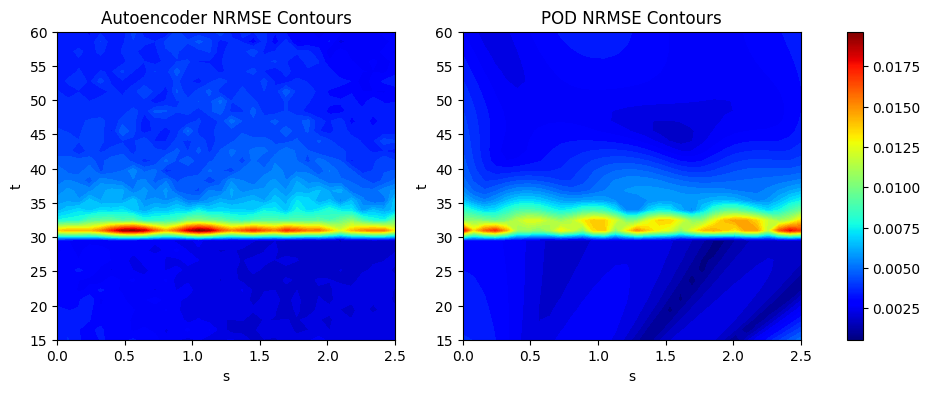

In [25]:
import numpy as np

# calculating the nrmse for each grid point
nrmse_autoencoder = evaluate_vector(true_values=xtest.flatten(1), predict_values=predictions, metric="nrmse").reshape(32,32).numpy(force=True)
print(f"Average value of NRMSE of autoencoder across grid: {np.mean(nrmse_autoencoder)}")

nrmse_pod = evaluate_vector(true_values=xtest.flatten(1), predict_values=predictions_pod.mT, metric="nrmse").reshape(32,32).numpy(force=True)
print(f"Average value of NRMSE of POD across grid: {np.mean(nrmse_pod)}")

# generating the min and max of the NRMSE contours
vmin = np.min([nrmse_autoencoder.min(), nrmse_pod.min()])
vmax = np.max([nrmse_autoencoder.max(), nrmse_pod.max()])

# plotting the nrmse contours for both models
fig, ax = plt.subplots(1,2, figsize=(12,4))
contour1 = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), nrmse_autoencoder, levels = 50, cmap='jet', vmin=vmin, vmax=vmax)
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder NRMSE Contours")

contour2 = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), nrmse_pod, levels = 50, cmap='jet', vmin=vmin, vmax=vmax)
ax[1].set_xlabel("s") 
ax[1].set_ylabel("t") 
ax[1].set_title("POD NRMSE Contours")

# normalzing the colorbar across both subplots
norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap='jet', norm=norm)
fig.colorbar(sm, ax=ax)